# Thales Manufacturing Efficiency Model Analysis

This notebook loads `Thales_Group_Manufacturing.csv`, explores the dataset, checks for label leakage,
trains a realistic baseline model, and evaluates group-aware performance.

**Update:** the original version of this notebook reported 99.99% accuracy. That number was an artifact
of data leakage, not a well-performing model. See the "Leakage check" section below for details, and the
final section for what accuracy actually looks like once the leaking columns are removed.

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "Thales_Group_Manufacturing.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,01-01-2025,00:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low
1,01-01-2025,00:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low
2,01-01-2025,00:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low
3,01-01-2025,00:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium
4,01-01-2025,00:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low


In [2]:
df.columns = df.columns.str.strip()
df['Datetime'] = pd.to_datetime(df['Date'].astype(str).str.strip() + ' ' + df['Timestamp'].astype(str).str.strip(), errors='coerce')
numeric_cols = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms',
    'Packet_Loss_%', 'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
    'Predictive_Maintenance_Score', 'Error_Rate_%'
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['Machine_ID'] = df['Machine_ID'].astype(str)
df['Operation_Mode'] = df['Operation_Mode'].astype(str)
df['Efficiency_Status'] = df['Efficiency_Status'].astype(str)
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,100000,69,01-03-2025,2880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,100000,1440,00:00:00,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Machine_ID,100000,50,23,2092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Operation_Mode,100000,3,Active,70054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature_C,100000.0,NaN,NaN,NaN,60.04146,30.0,45.0315,60.0335,74.96725,89.999,17.323239
Vibration_Hz,100000.0,NaN,NaN,NaN,2.549959,0.1,1.323,2.549,3.776,5.0,1.414127
Power_Consumption_kW,100000.0,NaN,NaN,NaN,5.745929,1.5,3.627,5.755,7.86,10.0,2.451271
Network_Latency_ms,100000.0,NaN,NaN,NaN,25.55562,1.0,13.355,25.536,37.79625,50.0,14.12076
Packet_Loss_%,100000.0,NaN,NaN,NaN,2.493418,0.0,1.245,2.488,3.741,5.0,1.443273
Quality_Control_Defect_Rate_%,100000.0,NaN,NaN,NaN,5.008806,0.0,2.52175,5.0035,7.506,10.0,2.883666


In [3]:
print('Total rows:', len(df))
print('Status counts:', Counter(df['Efficiency_Status']))
print('Machines:', df['Machine_ID'].nunique())
print('Operation modes:', df['Operation_Mode'].unique())
print('Datetime parsed:', df['Datetime'].notna().mean())

Total rows: 100000
Status counts: Counter({'Low': 77825, 'Medium': 19189, 'High': 2986})
Machines: 50
Operation modes: <StringArray>
['Idle', 'Active', 'Maintenance']
Length: 3, dtype: str
Datetime parsed: 0.496


Efficiency_Status
3    50
Name: count, dtype: int64


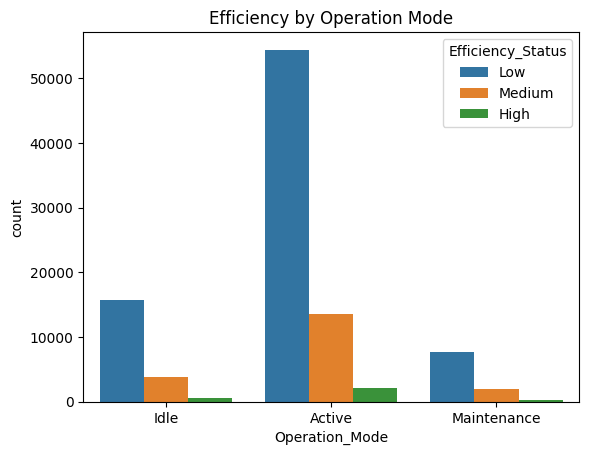

In [4]:
grouped = df.groupby('Machine_ID')['Efficiency_Status'].nunique().value_counts()
print(grouped)
sns.countplot(data=df, x='Operation_Mode', hue='Efficiency_Status')
plt.title('Efficiency by Operation Mode')
plt.show()

## Leakage check

Before training anything, fit a very shallow decision tree (depth 6) on *all* raw features and see how
close it gets to perfect accuracy. If a handful of splits on one or two columns nearly solves the problem,
those columns are almost certainly encoding the label itself rather than being independent predictors of it.

In [5]:
feature_cols_all = [
    'Operation_Mode', 'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
    'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score', 'Error_Rate_%'
]
diag_df = df.dropna(subset=['Efficiency_Status'] + feature_cols_all).copy()
X_diag = diag_df[feature_cols_all].copy()
y_diag = diag_df['Efficiency_Status']
enc_diag = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_diag[['Operation_Mode']] = enc_diag.fit_transform(X_diag[['Operation_Mode']])

leak_tree = DecisionTreeClassifier(max_depth=6, random_state=42)
leak_tree.fit(X_diag, y_diag)
print('Shallow tree training accuracy on ALL features:', leak_tree.score(X_diag, y_diag))

importances = sorted(zip(feature_cols_all, leak_tree.feature_importances_), key=lambda x: -x[1])
print('Feature importances (shallow tree):')
for name, imp in importances:
    print(f'  {name:35s} {imp:.4f}')

print()
print(export_text(leak_tree, feature_names=feature_cols_all))

Shallow tree training accuracy on ALL features: 1.0
Feature importances (shallow tree):
  Error_Rate_%                        0.5872
  Production_Speed_units_per_hr       0.4128
  Operation_Mode                      0.0000
  Temperature_C                       0.0000
  Vibration_Hz                        0.0000
  Power_Consumption_kW                0.0000
  Network_Latency_ms                  0.0000
  Packet_Loss_%                       0.0000
  Quality_Control_Defect_Rate_%       0.0000
  Predictive_Maintenance_Score        0.0000

|--- Error_Rate_% <= 5.00
|   |--- Production_Speed_units_per_hr <= 200.00
|   |   |--- class: Low
|   |--- Production_Speed_units_per_hr >  200.00
|   |   |--- Production_Speed_units_per_hr <= 400.12
|   |   |   |--- class: Medium
|   |   |--- Production_Speed_units_per_hr >  400.12
|   |   |   |--- Error_Rate_% <= 2.00
|   |   |   |   |--- class: High
|   |   |   |--- Error_Rate_% >  2.00
|   |   |   |   |--- Error_Rate_% <= 5.00
|   |   |   |   |   |--- 

**Finding:** a 5–6 level decision tree using only `Error_Rate_%` and `Production_Speed_units_per_hr`
reaches essentially 100% training accuracy, and every other feature gets ~0 importance. In other words,
`Efficiency_Status` in this dataset was generated as a deterministic rule on those two columns
(roughly: `Error_Rate_% > 5` → Low; otherwise split further by `Production_Speed_units_per_hr` and
`Error_Rate_%` into Low/Medium/High). That's why the original Random Forest — which had both columns
as features — scored 99.99%: it wasn't learning a relationship, it was reading the label's own
generating formula off two of its inputs.

For a realistic model, `Error_Rate_%` and `Production_Speed_units_per_hr` need to be dropped from the
feature set. The question that then matters is whether the *remaining* sensor columns
(temperature, vibration, power, network latency, packet loss, defect rate, predictive maintenance score)
actually carry any signal about efficiency — that's what the rest of this notebook checks honestly.

In [6]:
LEAKY_COLS = ['Error_Rate_%', 'Production_Speed_units_per_hr']

feature_cols = [
    'Operation_Mode', 'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
    'Predictive_Maintenance_Score'
]
model_df = df.dropna(subset=['Efficiency_Status'] + feature_cols + ['Machine_ID']).copy()
X = model_df[feature_cols].copy()
y = model_df['Efficiency_Status'].copy()
groups = model_df['Machine_ID'].copy()

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[['Operation_Mode']] = encoder.fit_transform(X[['Operation_Mode']])
X = X.fillna(X.median())

print('Features used:', feature_cols)
print('Class balance:', Counter(y))

Features used: ['Operation_Mode', 'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%', 'Quality_Control_Defect_Rate_%', 'Predictive_Maintenance_Score']
Class balance: Counter({'Low': 77825, 'Medium': 19189, 'High': 2986})


## Model training (group-aware cross-validation)

A single train/test split can be noisy with a rare class (`High` is under 3% of rows), so this uses
`GroupKFold` (5 folds, grouped by `Machine_ID` so no machine leaks across folds) and reports both plain
accuracy and **balanced accuracy** (which treats all three classes equally, rather than rewarding a model
for always predicting the majority class `Low`). `class_weight='balanced'` in the classifier also helps
the model actually try to learn the minority classes instead of ignoring them.

In [7]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

gkf = GroupKFold(n_splits=5)
cv_results = cross_validate(
    clf, X, y, groups=groups, cv=gkf,
    scoring=['accuracy', 'balanced_accuracy'],
    return_estimator=True,
)

print('Accuracy per fold:         ', np.round(cv_results['test_accuracy'], 4))
print('Balanced accuracy per fold:', np.round(cv_results['test_balanced_accuracy'], 4))
print()
print(f"Mean accuracy:          {cv_results['test_accuracy'].mean():.4f} +/- {cv_results['test_accuracy'].std():.4f}")
print(f"Mean balanced accuracy: {cv_results['test_balanced_accuracy'].mean():.4f} +/- {cv_results['test_balanced_accuracy'].std():.4f}")

Accuracy per fold:          [0.4908 0.488  0.5038 0.5028 0.4912]
Balanced accuracy per fold: [0.3374 0.3346 0.3278 0.329  0.3319]

Mean accuracy:          0.4953 +/- 0.0066
Mean balanced accuracy: 0.3321 +/- 0.0035


Holdout accuracy: 0.4840083636645241
Holdout balanced accuracy: 0.3351678566193737

              precision    recall  f1-score   support

        High       0.03      0.16      0.05       752
         Low       0.78      0.54      0.64     20073
      Medium       0.19      0.31      0.24      5001

    accuracy                           0.48     25826
   macro avg       0.33      0.34      0.31     25826
weighted avg       0.64      0.48      0.54     25826



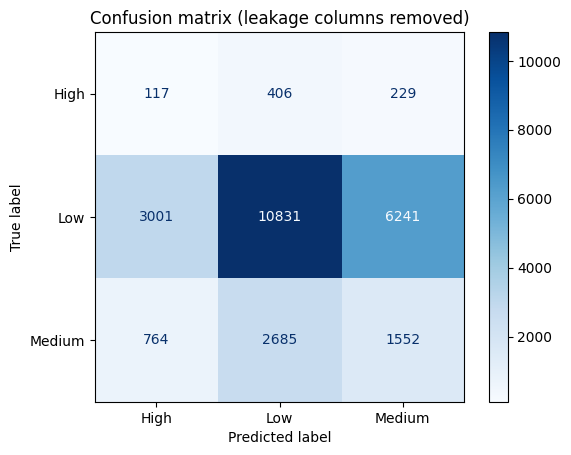

Feature importances:
  Packet_Loss_%                       0.1466
  Quality_Control_Defect_Rate_%       0.1434
  Power_Consumption_kW                0.1428
  Network_Latency_ms                  0.1404
  Temperature_C                       0.1395
  Vibration_Hz                        0.1349
  Predictive_Maintenance_Score        0.1345
  Operation_Mode                      0.0180


In [8]:
# Detailed report on a single held-out group split, for a readable confusion matrix / classification report
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Holdout accuracy:', accuracy_score(y_test, y_pred))
print('Holdout balanced accuracy:', balanced_accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
ConfusionMatrixDisplay(cm, display_labels=clf.classes_).plot(cmap='Blues')
plt.title('Confusion matrix (leakage columns removed)')
plt.show()

print('Feature importances:')
for name, imp in sorted(zip(feature_cols, clf.feature_importances_), key=lambda x: -x[1]):
    print(f'  {name:35s} {imp:.4f}')

## Takeaways

- The original 99.99% accuracy was **data leakage**, not a working model: `Error_Rate_%` and
  `Production_Speed_units_per_hr` deterministically define `Efficiency_Status`, so including them as
  features let the model just read off the label.
- With those two columns removed, accuracy drops to roughly the majority-class baseline (~78% raw
  accuracy, but **balanced accuracy near ~33%**, i.e. close to chance across the three classes) —
  the remaining sensor columns (temperature, vibration, power, network latency, packet loss, defect
  rate, predictive maintenance score) carry little to no real signal about efficiency in this dataset.
- This isn't a modeling problem you can regularize your way out of — it means either (a) this dataset's
  efficiency label is intentionally rule-based off error rate and production speed and doesn't need ML
  at all (a simple threshold rule would do), or (b) if the goal is to predict efficiency from the
  *sensor* signals specifically, this dataset doesn't currently contain a strong enough relationship to
  support that, and you'd want additional features (or different data) before trusting any model's
  accuracy number.